## 2026 NFL Fantasy WR Rankings Project Part 2 - WR Ranking

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
%matplotlib inline

C:\Users\kevin\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\kevin\anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\kevin\anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
final_wr = pd.read_csv('../outputs/final_wrs_model_data_2020_2026.csv')

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
pd.set_option('display.max_rows', None)

In [9]:
print(final_wr.columns.tolist())

['preseason_rank', 'player_name', 'season', 'past_season', 'player_age', 'team', 'team_qb', 'team_qb_season', 'team_qb_age', 'teammate', 'teammate_season', 'teammate_age', 'player_display_name', 'fantasy_points_ppr_pg', 'Previous_player_display_name', 'Previous_season', 'Previous_carries_pg', 'Previous_rushing_yards_pg', 'Previous_rushing_tds_pg', 'Previous_rushing_fumbles_pg', 'Previous_rushing_fumbles_lost_pg', 'Previous_rushing_first_downs_pg', 'Previous_rushing_2pt_conversions_pg', 'Previous_rushing_10_pg', 'Previous_rushing_12_pg', 'Previous_rushing_20_pg', 'Previous_rushing_40_pg', 'Previous_rushing_epa_pg', 'Previous_receptions_pg', 'Previous_targets_pg', 'Previous_receiving_yards_pg', 'Previous_receiving_tds_pg', 'Previous_receiving_fumbles_pg', 'Previous_receiving_fumbles_lost_pg', 'Previous_receiving_air_yards_pg', 'Previous_receiving_yards_after_catch_pg', 'Previous_receiving_first_downs_pg', 'Previous_receiving_2pt_conversions_pg', 'Previous_receiving_10_pg', 'Previous_rece

In [10]:
predictors = ['player_age', 'team_qb_age', 'teammate_age', 'Previous_carries_pg', 
              'Previous_rushing_yards_pg', 'Previous_rushing_tds_pg', 'Previous_rushing_fumbles_pg', 
              'Previous_rushing_fumbles_lost_pg', 'Previous_rushing_first_downs_pg', 
              'Previous_rushing_2pt_conversions_pg', 'Previous_rushing_10_pg', 'Previous_rushing_12_pg', 
              'Previous_rushing_20_pg', 'Previous_rushing_40_pg', 'Previous_rushing_epa_pg', 
              'Previous_receptions_pg', 'Previous_targets_pg', 'Previous_receiving_yards_pg', 
              'Previous_receiving_tds_pg', 'Previous_receiving_fumbles_pg', 
              'Previous_receiving_fumbles_lost_pg', 'Previous_receiving_air_yards_pg', 
              'Previous_receiving_yards_after_catch_pg', 'Previous_receiving_first_downs_pg', 
              'Previous_receiving_2pt_conversions_pg', 'Previous_receiving_10_pg', 'Previous_receiving_16_pg', 
              'Previous_receiving_20_pg', 'Previous_receiving_40_pg', 'Previous_air_yards_share_pg', 
              'Previous_wopr_pg', 'Previous_special_teams_tds_pg', 'Previous_punt_returns_pg', 
              'Previous_punt_return_yards_pg', 'Previous_kickoff_returns_pg', 'Previous_kickoff_return_yards_pg',
              'Previous_fantasy_points_ppr_pg', 'Previous_games_played', 'QB_completions_pg', 'QB_attempts_pg', 
              'QB_passing_yards_pg', 'QB_passing_tds_pg', 'QB_passing_interceptions_pg', 'QB_sacks_suffered_pg', 
              'QB_sack_yards_lost_pg', 'QB_sack_fumbles_pg', 'QB_sack_fumbles_lost_pg', 'QB_passing_air_yards_pg', 
              'QB_passing_yards_after_catch_pg', 'QB_passing_first_downs_pg', 'QB_passing_2pt_conversions_pg',
              'QB_passing_10_pg', 'QB_passing_16_pg', 'QB_passing_20_pg', 'QB_passing_40_pg', 'QB_passing_epa_pg', 
              'QB_passing_cpoe_pg', 'QB_fantasy_points_ppr_pg', 'QB_games_played', 'Teammate_carries_pg', 
              'Teammate_rushing_yards_pg', 'Teammate_rushing_tds_pg', 'Teammate_rushing_fumbles_pg',
              'Teammate_rushing_fumbles_lost_pg', 'Teammate_rushing_first_downs_pg', 'Teammate_rushing_2pt_conversions_pg',
              'Teammate_rushing_10_pg', 'Teammate_rushing_12_pg', 'Teammate_rushing_20_pg', 'Teammate_rushing_40_pg',
              'Teammate_rushing_epa_pg', 'Teammate_receptions_pg', 'Teammate_targets_pg', 'Teammate_receiving_yards_pg',
              'Teammate_receiving_tds_pg', 'Teammate_receiving_fumbles_pg', 'Teammate_receiving_fumbles_lost_pg',
              'Teammate_receiving_air_yards_pg', 'Teammate_receiving_yards_after_catch_pg',
              'Teammate_receiving_first_downs_pg', 'Teammate_receiving_2pt_conversions_pg', 'Teammate_receiving_10_pg',
              'Teammate_receiving_16_pg', 'Teammate_receiving_20_pg', 'Teammate_receiving_40_pg',
              'Teammate_air_yards_share_pg', 'Teammate_wopr_pg', 'Teammate_special_teams_tds_pg',
              'Teammate_punt_returns_pg', 'Teammate_punt_return_yards_pg', 'Teammate_kickoff_returns_pg',
              'Teammate_kickoff_return_yards_pg', 'Teammate_fantasy_points_ppr_pg', 'Teammate_games_played'
             ]

narrowed_predictors = ['player_age', 'team_qb_age', 'teammate_age', 'Previous_carries_pg', 
              'Previous_rushing_yards_pg', 'Previous_rushing_tds_pg', 
              'Previous_receptions_pg', 'Previous_targets_pg', 'Previous_receiving_yards_pg', 
              'Previous_receiving_tds_pg', 'Previous_fantasy_points_ppr_pg', 'Previous_games_played', 'QB_completions_pg', 
              'QB_attempts_pg', 'QB_passing_yards_pg', 'QB_passing_tds_pg',  'QB_fantasy_points_ppr_pg', 'QB_games_played', 
              'Teammate_carries_pg', 'Teammate_rushing_yards_pg', 'Teammate_rushing_tds_pg',
              'Teammate_receptions_pg', 'Teammate_targets_pg', 'Teammate_receiving_yards_pg',
              'Teammate_receiving_tds_pg', 'Teammate_fantasy_points_ppr_pg', 'Teammate_games_played'
             ]

target = ['fantasy_points_ppr_pg']

In [12]:
final_wr['season'].unique()

array([2021, 2022, 2023, 2024, 2025, 2026], dtype=int64)

### Linear Regression v1 (Full Features)

In [14]:
train = final_wr[final_wr["season"].isin([2021, 2022, 2023, 2024])]
test = final_wr[final_wr["season"] == 2025]
projections = final_wr[final_wr["season"] == 2026]

In [15]:
lm_full = LinearRegression()

In [16]:
lm_full.fit(train[predictors],train[target])

LinearRegression()

In [17]:
def create_prediction(lm, test, predictors):
    predictions = lm.predict(test[predictors])
    predictions = pd.DataFrame(predictions, columns=["predictions"], index=test.index)
    combination = pd.concat([test[["player_name", "season", "fantasy_points_ppr_pg"]], predictions], axis=1)
    return combination

In [18]:
combination = create_prediction(lm_full, test, predictors)

In [21]:
def show_model_results(combination):
    mae = metrics.mean_absolute_error(
        combination["fantasy_points_ppr_pg"],
        combination["predictions"]
    )

    mse = metrics.mean_squared_error(
        combination["fantasy_points_ppr_pg"],
        combination["predictions"]
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        combination["fantasy_points_ppr_pg"],
        combination["predictions"]
    )

    print(f"MAE: {mae:.3f}")
    print(f"MSE: {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R-squared: {r2:.3f}")

In [20]:
show_model_results(combination)

MAE: 4.925
MSE: 41.183
RMSE: 6.417
R-squared: -1.024


In [22]:
def show_outliers(combination):
    combination["squared_error"] = (
        combination["predictions"]
        - combination["fantasy_points_ppr_pg"]
    ) ** 2

    print(combination.sort_values("squared_error", ascending=False).head(10))

In [23]:
show_outliers(combination)

         player_name  season  fantasy_points_ppr_pg  predictions  \
234      Chris Olave    2025              16.750000    -3.956321   
241    Calvin Ridley    2025               6.757143    20.360721   
259    Brandon Aiyuk    2025               0.000000    13.040235   
262   Darnell Mooney    2025               5.486667    18.115212   
229   Terry McLaurin    2025              11.420000    23.532707   
260     Chris Godwin    2025               9.222222    20.498848   
264  Diontae Johnson    2025               0.000000    10.678180   
238   George Pickens    2025              17.170588     6.823142   
233    Xavier Worthy    2025               7.850000    17.107879   
257      Jayden Reed    2025               9.700000    17.801058   

     squared_error  
234     428.751714  
241     185.057337  
259     170.047727  
262     159.480145  
229     146.717662  
260     127.162286  
264     114.023533  
238     107.069653  
233      85.708315  
257      65.627138  


This v1 model with all the predictors is not very good so we will try a v2 with a narrowed set of features to try to avoid overfitting. This v1 produced a negative R-squared, which is not good.

### Linear Regression v2 (Narrowed features)

In [24]:
lm_narrowed = LinearRegression()

In [25]:
lm_narrowed.fit(train[narrowed_predictors],train[target])

LinearRegression()

In [26]:
combination = create_prediction(lm_narrowed, test, narrowed_predictors)

In [27]:
show_model_results(combination)

MAE: 2.916
MSE: 14.356
RMSE: 3.789
R-squared: 0.295


This is much better as it now shows a positive R-squared, with a value of 0.295.

In [28]:
show_outliers(combination)

         player_name  season  fantasy_points_ppr_pg  predictions  \
234      Chris Olave    2025              16.750000     7.150491   
217       Puka Nacua    2025              23.437500    15.310757   
239      Jerry Jeudy    2025               7.100000    15.199977   
259    Brandon Aiyuk    2025               0.000000     8.013161   
264  Diontae Johnson    2025               0.000000     7.410654   
262   Darnell Mooney    2025               5.486667    12.420291   
230      Rashee Rice    2025              18.762500    11.911043   
260     Chris Godwin    2025               9.222222    15.187304   
238   George Pickens    2025              17.170588    11.368170   
240     Deebo Samuel    2025              11.762500     6.595193   

     squared_error  
234      92.150580  
217      66.043949  
239      65.609631  
259      64.210748  
264      54.917798  
262      48.075146  
230      46.942469  
260      35.582202  
238      33.668059  
240      26.701060  


In [29]:
# Scale predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train[narrowed_predictors])

# Add intercept
X_train_scaled = sm.add_constant(X_train_scaled)

# Fit OLS model
model = sm.OLS(train[target], X_train_scaled).fit()

# Get coefficients + p-values
coefficients = pd.DataFrame({
    "Predictor": ["Intercept"] + narrowed_predictors,
    "Coefficient": model.params,
    "P-value": model.pvalues
})

coefficients["Absolute"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values("P-value", ascending=True)

print(coefficients)

                            Predictor  Coefficient        P-value   Absolute
const                       Intercept    12.646039  8.501061e-111  12.646039
x12             Previous_games_played     0.757460   6.877872e-03   0.757460
x17          QB_fantasy_points_ppr_pg    -1.466661   2.379825e-02   1.466661
x1                         player_age    -0.614788   3.129040e-02   0.614788
x16                 QB_passing_tds_pg     1.365855   4.481136e-02   1.365855
x21           Teammate_rushing_tds_pg     1.148994   1.802535e-01   1.148994
x2                        team_qb_age    -0.337663   2.543753e-01   0.337663
x3                       teammate_age     0.302474   2.954906e-01   0.302474
x15               QB_passing_yards_pg     1.201937   3.446404e-01   1.201937
x8                Previous_targets_pg     0.789898   3.550328e-01   0.789898
x4                Previous_carries_pg    -0.629273   3.551835e-01   0.629273
x19               Teammate_carries_pg    -0.585673   3.832830e-01   0.585673

**The following predictors ended up being significant: previous games played, the QB's fantasy points per game last season, the player's age, and the QB's passing TDs last season. This goes to show that performance is heavily predicated on the age curve of a player's development and how good their QB is (offensive opportunity). What's surprising is that this is less heavily influenced by the other teammate on their team.**

### Ridge Regression

In [30]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge.fit(
    train[narrowed_predictors],
    train[target]
)

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])

In [32]:
predictions = ridge.predict(test[narrowed_predictors])

print("MAE:", mean_absolute_error(test[target], predictions))
print("R²:", r2_score(test[target], predictions))

MAE: 2.8687665655830954
R²: 0.31367964895394373


By introducing a Ridge regression to limit overfitting, we were able to bring slight improvements to our linear model v2 and improve the R-squared from 0.295 to 0.314, while decreasing the mean absolute error.

### 2026 Projections - Ridge Regression

In [33]:
projections["Predicted_Fantasy_PPR_PG"] = ridge.predict(projections[narrowed_predictors])

projections = projections.sort_values(
    "Predicted_Fantasy_PPR_PG",
    ascending=False
)

print(projections[["player_name", "season", "Predicted_Fantasy_PPR_PG"]])

            player_name  season  Predicted_Fantasy_PPR_PG
269          Puka Nacua    2026                 22.257634
270       Ja'Marr Chase    2026                 19.463755
271  Jaxon Smith-Njigba    2026                 18.078244
272   Amon-Ra St. Brown    2026                 17.191372
273        Drake London    2026                 15.609300
278      George Pickens    2026                 15.599432
279         Chris Olave    2026                 15.305529
306   Wan'Dale Robinson    2026                 14.579386
284   Tetairoa McMillan    2026                 14.436620
282         Zay Flowers    2026                 14.104562
280        Nico Collins    2026                 13.916665
285         Tee Higgins    2026                 13.819727
292    Jameson Williams    2026                 13.797695
276          A.J. Brown    2026                 13.788547
286        Emeka Egbuka    2026                 13.773904
308      Michael Wilson    2026                 13.764207
274         Ce

C:\Users\kevin\AppData\Local\Temp\ipykernel_15184\2476470254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  projections["Predicted_Fantasy_PPR_PG"] = ridge.predict(projections[narrowed_predictors])


In [75]:
def plot_fantasy_tiers(
    df,
    prediction_col="Predicted_Fantasy_PPR_PG",
    player_col="player_name"
):
    # Create tier labels
    def assign_tier(points):
        if points >= 14.4:
            return "WR 1 Range"
        elif points >= 12:
            return "WR 2 Range"
        elif points >= 10.5:
            return "WR 3 Range"
        else:
            return "Not Relevant"

    # Avoid modifying original dataframe
    plot_df = df.copy()

    plot_df["Tier"] = plot_df[prediction_col].apply(assign_tier)

    # Assign colors
    tier_colors = {
        "WR 1 Range": "blue",
        "WR 2 Range": "green",
        "WR 3 Range": "orange",
        "Not Relevant": "gray"
    }

    # Sort for horizontal bar chart
    plot_df = plot_df.sort_values(
        prediction_col,
        ascending=True
    )

    colors = plot_df["Tier"].map(tier_colors)

    # Plot
    plt.figure(figsize=(10, max(6, len(plot_df) * 0.35)))

    plt.barh(
        plot_df[player_col],
        plot_df[prediction_col],
        color=colors
    )

    # Add value labels
    for i, row in plot_df.reset_index(drop=True).iterrows():
        plt.text(
            row[prediction_col] + 0.1,
            i,
            f'{row[prediction_col]:.1f}',
            va="center"
        )

    plt.xlabel("Predicted Fantasy PPR Points Per Game")
    plt.ylabel("Player")
    plt.title("Fantasy PPR WR Projections by Tier")

    # Add legend
    legend_elements = [
        Patch(facecolor="blue", label="WR 1 (14.4+)"),
        Patch(facecolor="green", label="WR 2 (12+)"),
        Patch(facecolor="orange", label="WR 3 (10.5+)"),
        Patch(facecolor="gray", label="Late round")
    ]

    plt.legend(handles=legend_elements)

    plt.tight_layout()
    
    return plt.gcf()

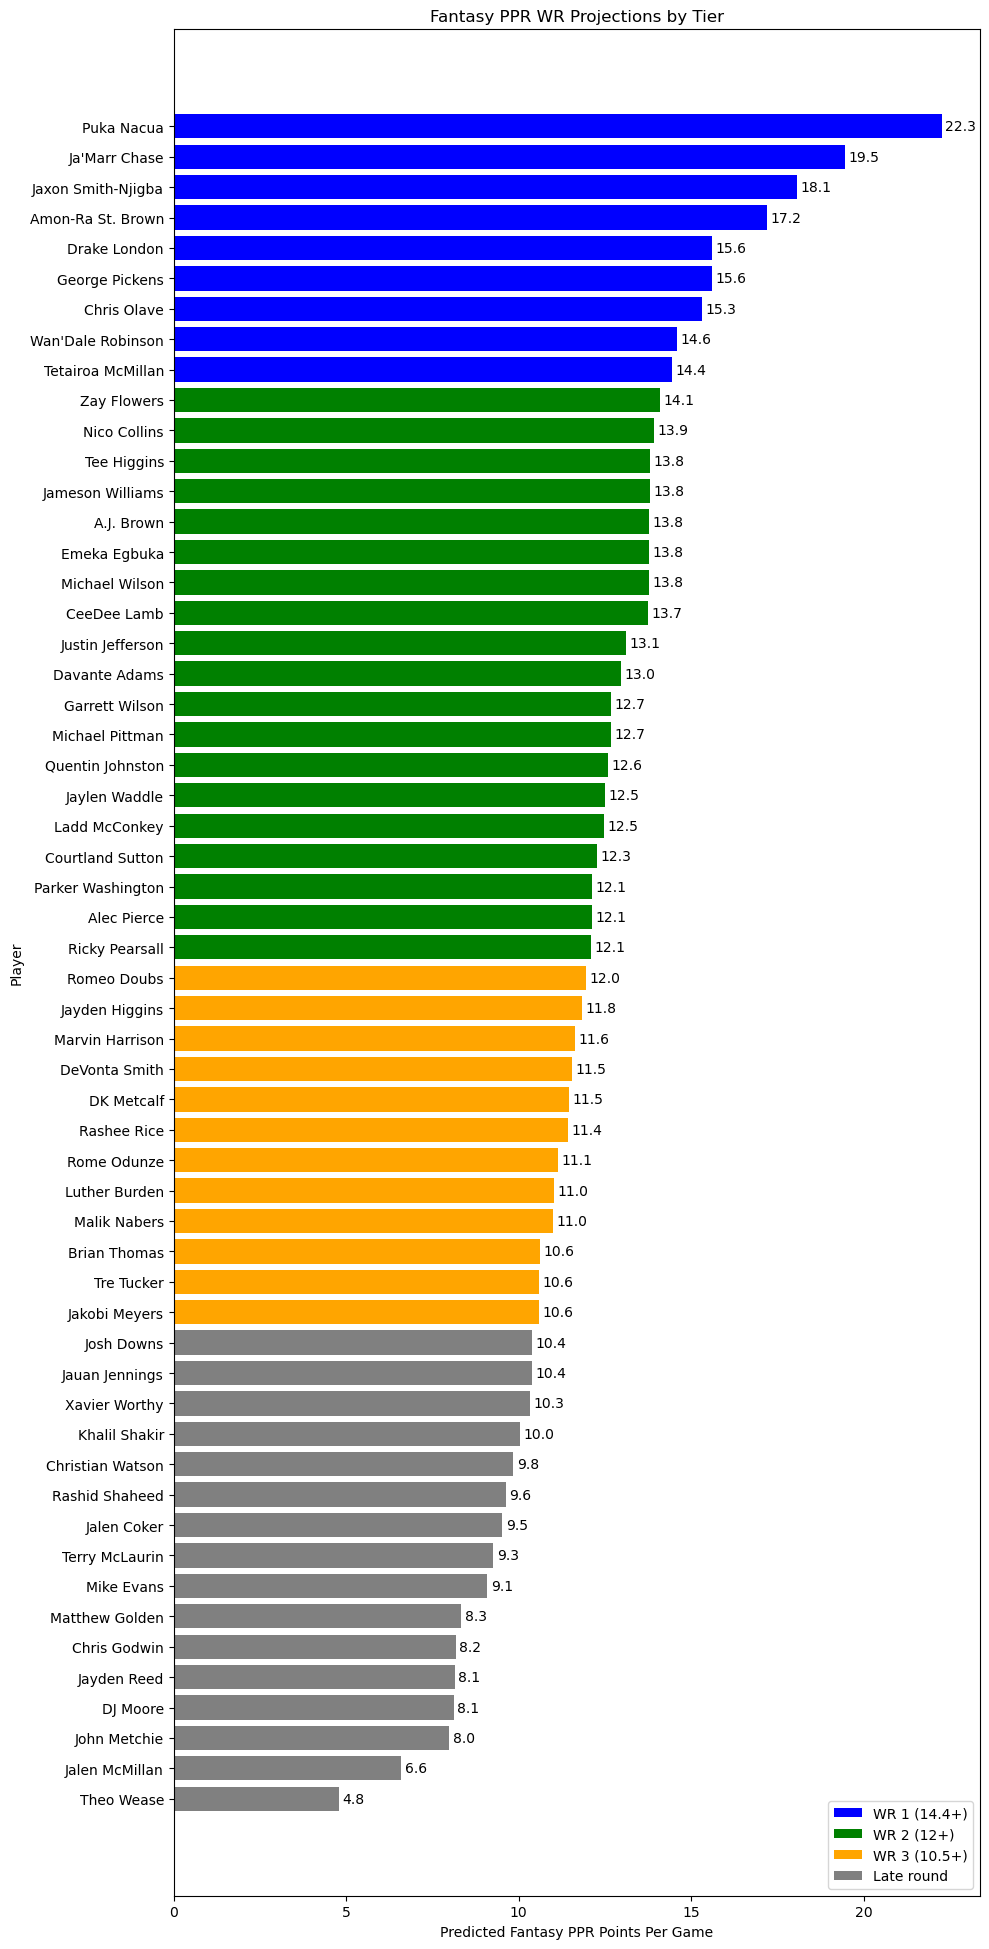

In [44]:
fig = plot_fantasy_tiers(
    projections,
    prediction_col="Predicted_Fantasy_PPR_PG",
    player_col="player_name"
)

fig.savefig(
    "../images/ridge_2026_wr_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

**A few surprises:**
- This Ridge model projects Wan'Dale Robinson to be a WR1, which no one is expecting. The one caveat here is that this model does not account for rookie WR teammates or rookie QBs because there is no historical data to pull from. This is one case where that shows its effect has Robinson will be joined by a rookie WR Carnell Tate, who was a top 5 pick in the real NFL Draft. I would take the Robinson projection with a grain of salt although the outputs earlier showed that teammate performance was not a significant predictor. However, the coefficient for teammate fantasy points per game was negative and quite large, so had Tate's projections been folded in maybe it would have brought his projection down.
- Other surprises here include Rashee Rice, Devonta Smith, and Malik Nabers being much lower than expected.

### XG Boost v1 (Full features)

In [45]:
train = final_wr[final_wr["season"].isin([2021, 2022, 2023, 2024])]
test = final_wr[final_wr["season"] == 2025]
projections = final_wr[final_wr["season"] == 2026]

In [46]:
# Use your longer predictor set
X_train = train[predictors]
X_test = test[predictors]

y_train = train[target]
y_test = test[target]

In [47]:
def find_best_params(X_train, y_train):
    # Parameter search space
    param_dist = {
        "n_estimators": [50, 100, 150, 200, 300, 500],
        "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.1],
        "max_depth": [1, 2, 3, 4],
        "min_child_weight": [1, 3, 5, 10],
        "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
        "gamma": [0, 0.1, 0.3, 0.5, 1],
        "reg_alpha": [0, 0.5, 1, 2, 5],
        "reg_lambda": [1, 5, 10, 20, 50]
    }

    # Base model
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    )

    # Random search
    random_search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=100,          # Number of parameter combinations to test
        scoring="r2",
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    # Fit
    random_search.fit(X_train, y_train)

    # Best results
    print("Best CV R²:", random_search.best_score_)
    print("\nBest Parameters:")
    print(random_search.best_params_)

In [48]:
find_best_params(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best CV R²: 0.24708092709692164

Best Parameters:
{'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.6}


In [50]:
# Create model
xgb_model_full = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.7,
    colsample_bytree=0.6,
    reg_alpha=0.0,
    reg_lambda=10,
    random_state=42
)

# Train
xgb_model_full.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [52]:
# Predict
predictions = xgb_model_full.predict(X_test)

In [53]:
# Evaluate
print("MAE:", mean_absolute_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("R²:", r2_score(y_test, predictions))

MAE: 2.841594618774352
RMSE: 3.7215896533192776
R²: 0.31945436885940515


This model only slightly improved our performance from the Ridge regression with an R-squared of 0.313 to 0.319.

### XG Boost v2 (Narrowed features)

In [54]:
# Use your longer predictor set
X_train_2 = train[narrowed_predictors]
X_test_2 = test[narrowed_predictors]

y_train_2 = train[target]
y_test_2 = test[target]

In [55]:
find_best_params(X_train_2, y_train_2)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best CV R²: 0.23387660647201564

Best Parameters:
{'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 50, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [71]:
# Create model
xgb_model_narrowed = XGBRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.6,
    colsample_bytree=0.6,
    reg_alpha=0.5,
    reg_lambda=5,
    random_state=42
)

# Train
xgb_model_narrowed.fit(
    X_train_2,
    y_train_2
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [72]:
predictions = xgb_model_narrowed.predict(X_test_2)

In [73]:
# Evaluate
print("MAE:", mean_absolute_error(y_test_2, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test_2, predictions)))
print("R²:", r2_score(y_test_2, predictions))

MAE: 2.95805062257713
RMSE: 3.7939873543294675
R²: 0.2927189259270806


Even with a narrowed set of predictors, we were unable to beat the performance from the first version of the XG Boost.

### 2026 Projections - XG Boost (Full Features)

In [74]:
# Generate XGBoost predictions
projections["Predicted_Fantasy_PPR_PG"] = xgb_model_full.predict(
    projections[predictors]
)

# Sort by projected fantasy points
projections= projections.sort_values(
    "Predicted_Fantasy_PPR_PG",
    ascending=False
)

# Display results
print(
    projections[
        ["player_name", "season", "Predicted_Fantasy_PPR_PG"]
    ]
)

            player_name  season  Predicted_Fantasy_PPR_PG
272   Amon-Ra St. Brown    2026                 18.513134
270       Ja'Marr Chase    2026                 18.184464
269          Puka Nacua    2026                 17.540674
277         Rashee Rice    2026                 17.088747
278      George Pickens    2026                 16.930990
273        Drake London    2026                 15.651105
271  Jaxon Smith-Njigba    2026                 15.512253
296          DK Metcalf    2026                 15.364560
279         Chris Olave    2026                 14.864882
308      Michael Wilson    2026                 14.839454
275    Justin Jefferson    2026                 14.816441
292    Jameson Williams    2026                 14.448748
300    Courtland Sutton    2026                 14.353954
276          A.J. Brown    2026                 14.111221
280        Nico Collins    2026                 14.068557
274         CeeDee Lamb    2026                 13.988603
291       Jayl

C:\Users\kevin\AppData\Local\Temp\ipykernel_15184\3428698127.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  projections["Predicted_Fantasy_PPR_PG"] = xgb_model_full.predict(


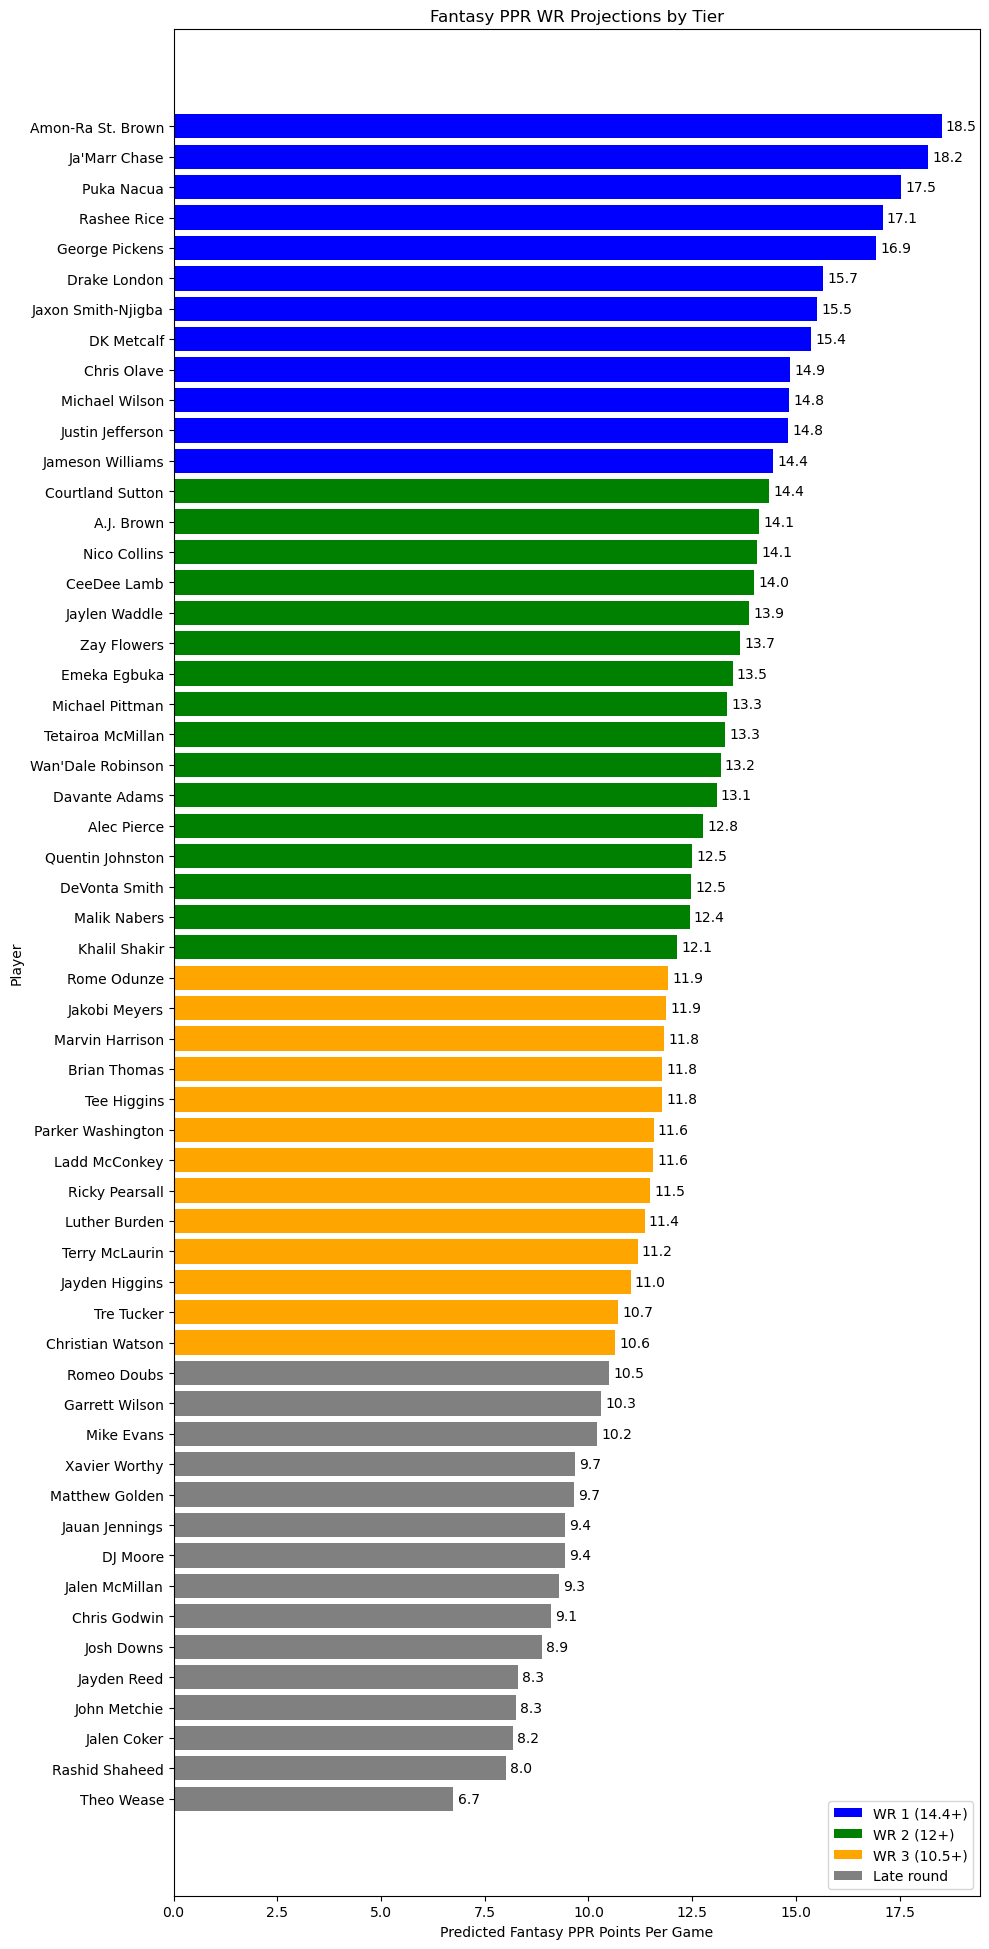

In [77]:
fig = plot_fantasy_tiers(
    projections,
    prediction_col="Predicted_Fantasy_PPR_PG",
    player_col="player_name"
)

fig.savefig(
    "../images/xgb_2026_wr_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

The projections here correct some surprises from the previous ridge model, such as moving Rashee Rice up to a WR1 and Wan'Dale Robinson down to a WR2. However, some other surprises come up such as Michael Wilson being a WR1 and Ceedee Lamb not being a WR1, likely because Wilson overachieved last season and Lamb underachieved. That leads me to believe this model favored the player's performance in the previous season. Because projections are so different here, an ensemble model could once again be useful.

In [78]:
def find_xgb_feature_importance(predictors, xgb_model):
    importance = pd.DataFrame({
        "Feature": predictors,
        "Importance": xgb_model.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    print(importance)

In [79]:
find_xgb_feature_importance(predictors, xgb_model_full)

                                    Feature  Importance
36           Previous_fantasy_points_ppr_pg    0.065812
17              Previous_receiving_yards_pg    0.049223
23        Previous_receiving_first_downs_pg    0.042413
16                      Previous_targets_pg    0.040543
30                         Previous_wopr_pg    0.033238
15                   Previous_receptions_pg    0.023580
22  Previous_receiving_yards_after_catch_pg    0.019500
25                 Previous_receiving_10_pg    0.019474
18                Previous_receiving_tds_pg    0.017653
40                      QB_passing_yards_pg    0.017208
38                        QB_completions_pg    0.017089
57                 QB_fantasy_points_ppr_pg    0.016988
51                         QB_passing_10_pg    0.015251
37                    Previous_games_played    0.015217
68                   Teammate_rushing_20_pg    0.015183
24    Previous_receiving_2pt_conversions_pg    0.015097
74                Teammate_receiving_tds_pg    0

The feature importances here all showcase that, showing that the most important features are all the player's previous season performance. This is opposite what the linear model prioritized, so another good indicator to perform an ensemble model.

### Ensemble Model

In [80]:
# Ensemble weights
ridge_weight = 0.5
xgb_weight = 0.5

Because both models performed at about the same 0.31 R-squared, I will just use the same weights.

In [81]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge.fit(
    train[narrowed_predictors],
    train[target]
)

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])

In [82]:
# Create model
xgb_model_full = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.7,
    colsample_bytree=0.6,
    reg_alpha=0.0,
    reg_lambda=10,
    random_state=42
)

# Train
xgb_model_full.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [84]:
ridge_pred = ridge.predict(test[narrowed_predictors]).flatten()
xgb_pred = xgb_model_full.predict(X_test)

In [85]:
# Ensemble prediction
ensemble_pred = (
    ridge_weight * ridge_pred +
    xgb_weight * xgb_pred
)

In [86]:
# Create results dataframe
ensemble_results = test[["player_name", "season", "fantasy_points_ppr_pg"]].copy()

ensemble_results["Ridge Prediction"] = ridge_pred
ensemble_results["XGBoost Prediction"] = xgb_pred
ensemble_results["Ensemble Prediction"] = ensemble_pred

# Print predictions
print(ensemble_results.sort_values("Ensemble Prediction", ascending=False))

            player_name  season  fantasy_points_ppr_pg  Ridge Prediction  \
212       Ja'Marr Chase    2025              19.600000         20.990859   
216        Malik Nabers    2025              14.275000         16.679588   
235  Jaxon Smith-Njigba    2025              21.170588         16.662295   
217          Puka Nacua    2025              23.437500         15.445160   
221        Drake London    2025              16.825000         16.179691   
215   Amon-Ra St. Brown    2025              19.058824         16.547575   
260        Chris Godwin    2025               9.222222         15.381096   
219        Brian Thomas    2025               9.914286         15.558862   
218        Nico Collins    2025              15.080000         15.317561   
225         Tee Higgins    2025              14.106667         16.037592   
214    Justin Jefferson    2025              11.852941         15.648102   
224      Garrett Wilson    2025              14.214286         13.876121   
228         

In [87]:
# Evaluate ensemble
mae = mean_absolute_error(test[target], ensemble_pred)
mse = mean_squared_error(test[target], ensemble_pred)
rmse = np.sqrt(mse)
r2 = r2_score(test[target], ensemble_pred)

print("\nEnsemble Performance")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R-squared: {r2:.3f}")


Ensemble Performance
MAE: 2.757
MSE: 13.336
RMSE: 3.652
R-squared: 0.345


This ensemble model, although still modest at an R-squared of 0.345, is clearly the best model amongst all tested.

### 2026 Simulation and Projection - Ensemble Model

In [88]:
n_bootstrap = 1000

bootstrap_predictions = []

for i in range(n_bootstrap):

    # Bootstrap sample
    boot = resample(train, replace=True, random_state=i)

    # Fit both models
    ridge.fit(
        boot[narrowed_predictors],
        boot[target].values.ravel()
    )
    
    xgb_model_full.fit(boot[predictors], boot[target].values.ravel())

    # Predict 2026 rookies
    ridge_pred = ridge.predict(projections[narrowed_predictors]).flatten()
    xgb_pred = xgb_model_full.predict(projections[predictors])
    

    # Ensemble prediction
    ensemble_pred = (
        ridge_weight * ridge_pred +
        xgb_weight * xgb_pred
    )

    bootstrap_predictions.append(ensemble_pred)

bootstrap_predictions = np.array(bootstrap_predictions)

In [90]:
summary_ensemble = pd.DataFrame({
    "Name": projections["player_name"].values,
    "Mean": bootstrap_predictions.mean(axis=0),
    "Std": bootstrap_predictions.std(axis=0),
    "5th Percentile": np.percentile(bootstrap_predictions, 2.5, axis=0),
    "95th Percentile": np.percentile(bootstrap_predictions, 97.5, axis=0),
})

summary_ensemble["P(WR1)"] = (bootstrap_predictions >= 14.4).mean(axis=0)
summary_ensemble["P(WR2)"] = (
    ((bootstrap_predictions >= 12.5) &
     (bootstrap_predictions < 14.4))
).mean(axis=0)
summary_ensemble["P(WR3)"] = (
    ((bootstrap_predictions >= 10) &
     (bootstrap_predictions < 12.5))
).mean(axis=0)

summary_ensemble["P(Not Relevant)"] = (
    (bootstrap_predictions < 10)
).mean(axis=0)

summary_ensemble = summary_ensemble.sort_values("Mean", ascending=False)

In [91]:
summary_ensemble

,Name,Mean,Std,5th Percentile,95th Percentile,P(WR1),P(WR2),P(WR3),P(Not Relevant)
2,Puka Nacua,20.063570,0.964635,18.086727,21.924352,1.000,0.000,0.000,0.000
1,Ja'Marr Chase,18.686045,0.819433,17.056037,20.296347,1.000,0.000,0.000,0.000
0,Amon-Ra St. Brown,17.689166,0.791690,16.117847,19.266984,1.000,0.000,0.000,0.000
6,Jaxon Smith-Njigba,16.987141,0.929008,15.215388,18.775255,0.997,0.003,0.000,0.000
4,George Pickens,16.349182,0.776256,14.935557,17.780523,0.997,0.003,0.000,0.000
5,Drake London,15.464908,0.871688,13.774836,17.219602,0.891,0.109,0.000,0.000
8,Chris Olave,15.146898,0.755649,13.674587,16.577462,0.837,0.162,0.001,0.000
9,Michael Wilson,14.206146,0.649165,12.874145,15.442974,0.388,0.608,0.004,0.000
15,CeeDee Lamb,14.121526,0.718416,12.734210,15.622777,0.322,0.665,0.013,0.000
13,A.J. Brown,13.998561,0.670458,12.611109,15.268690,0.286,0.693,0.021,0.000


In [92]:
summary_ensemble.to_csv('../outputs/ensemble_wrs_2026_prediction.csv', index=False)

In [ ]:
summary_ensemble = pd.read_csv('../outputs/ensemble_wrs_2026_prediction.csv')

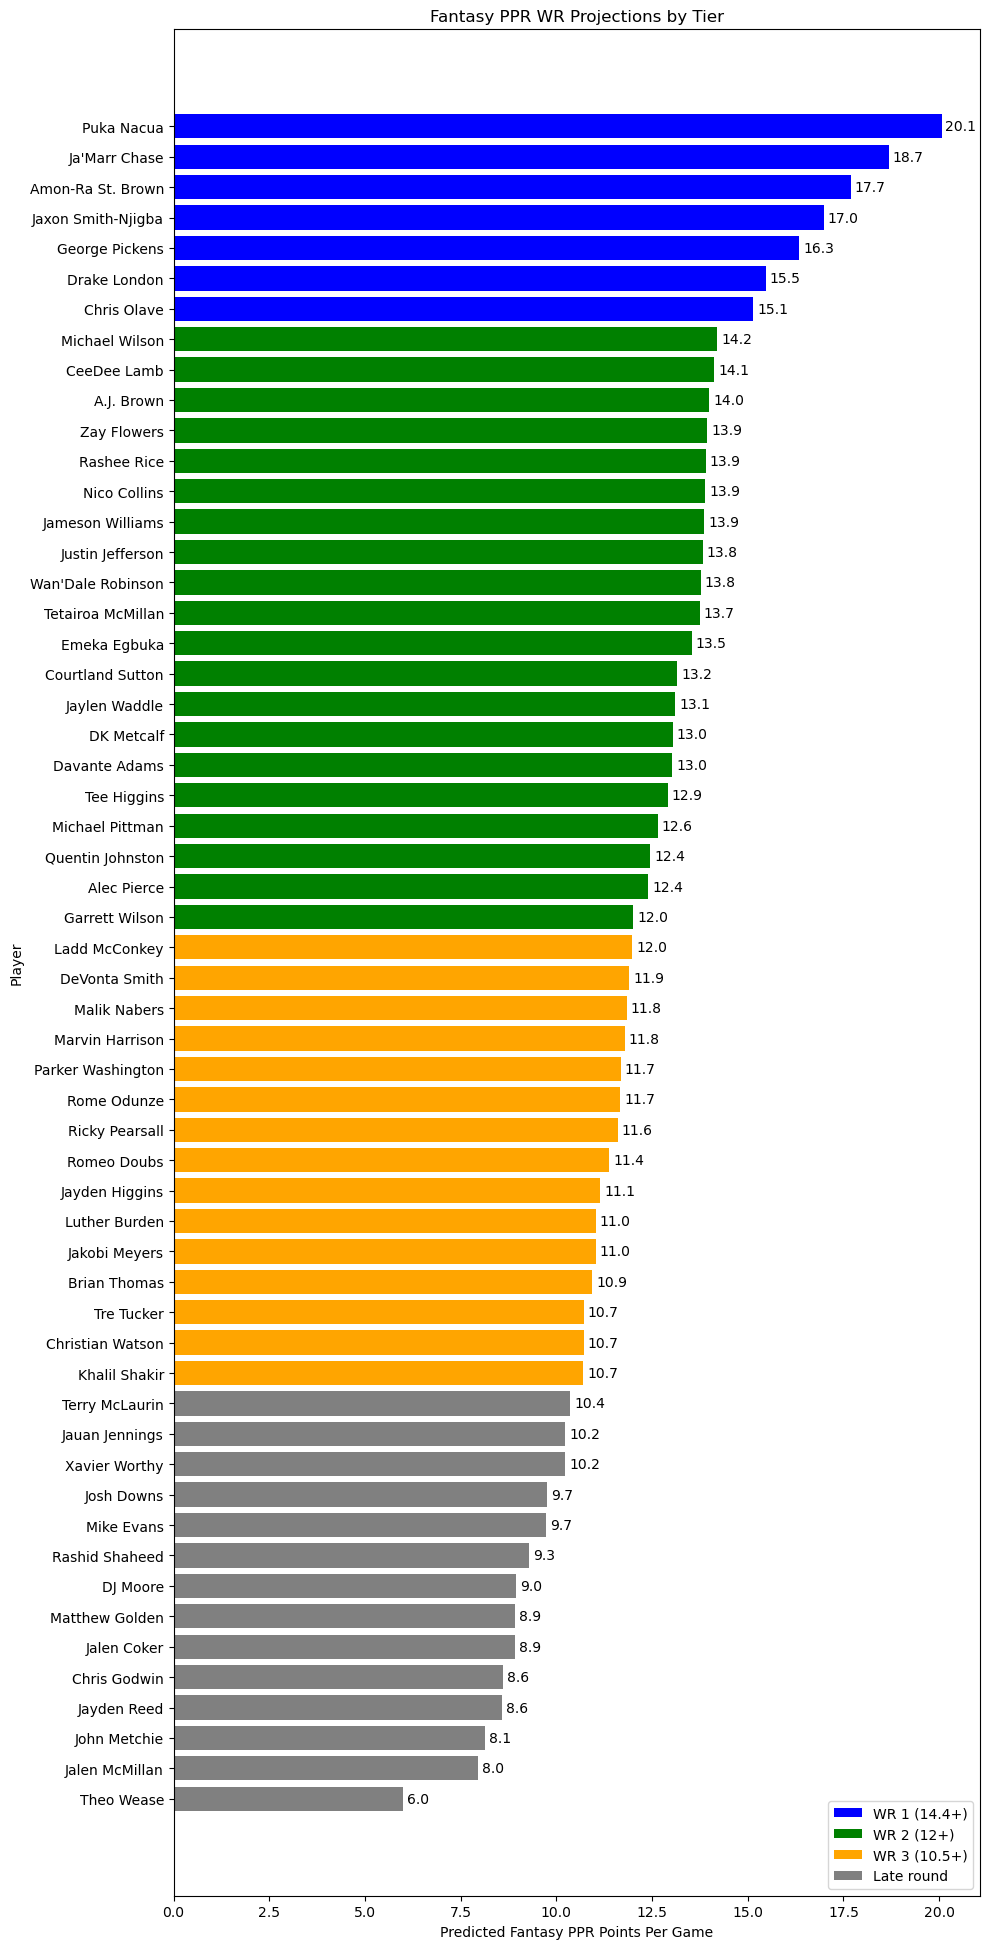

In [94]:
fig = plot_fantasy_tiers(
    summary_ensemble,
    prediction_col="Mean",
    player_col="Name"
)

fig.savefig(
    "../images/ensemble_2026_wr_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

In [98]:
def plot_prediction_intervals(summary):
    plot_df = summary.sort_values("Mean", ascending=True)

    # Distance from mean to interval bounds
    lower_error = plot_df["Mean"] - plot_df["5th Percentile"]
    upper_error = plot_df["95th Percentile"] - plot_df["Mean"]

    plt.figure(figsize=(10, max(6, len(plot_df) * 0.35)))

    plt.errorbar(
        plot_df["Mean"],
        plot_df["Name"],
        xerr=[lower_error, upper_error],
        fmt="o",
        capsize=4
    )

    plt.xlabel("Projected Fantasy PPR Points Per Game")
    plt.ylabel("Player")
    plt.title("2026 Rookie Fantasy Projections\nMean with 90% Prediction Interval")

    plt.grid(axis="x", alpha=.3)

    plt.tight_layout()
    return plt.gcf()

In [104]:
def plot_tier_probabilities(summary):

    # Sort from lowest to highest so the best players appear at the top
    plot_df = summary.sort_values("Mean", ascending=True)

    wr1 = plot_df["P(WR1)"] * 100
    wr2 = plot_df["P(WR2)"] * 100
    wr3 = plot_df["P(WR3)"] * 100
    irrelevant = plot_df["P(Not Relevant)"] * 100

    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.35)))

    # Stacked horizontal bars
    ax.barh(
        plot_df["Name"],
        wr1,
        label="WR1 (14.4+)",
        color="blue"
    )

    ax.barh(
        plot_df["Name"],
        wr2,
        left=wr1,
        label="WR2 (12-14.4)",
        color="green"
    )
    
    ax.barh(
        plot_df["Name"],
        wr3,
        left=wr1 + wr2,
        label="WR3 (10.5-12)",
        color="orange"
    )

    ax.barh(
        plot_df["Name"],
        irrelevant,
        left=wr1 + wr2 + wr3,
        label="Not Relevant (<10.5)",
        color="gray"
    )

    ax.set_xlabel("Simulation Probability (%)")
    ax.set_ylabel("Player")
    ax.set_xlim(0, 100)

    # Figure title
    fig.suptitle(
        "Probability of Falling into Each Fantasy Tier",
        fontsize=15,
        fontweight="bold",
        y=0.89
    )

    # Legend below title
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=3,
        frameon=False
    )

    # Leave room for title and legend
    fig.tight_layout(rect=[0, 0, 1, 0.90])

    return plt.gcf()

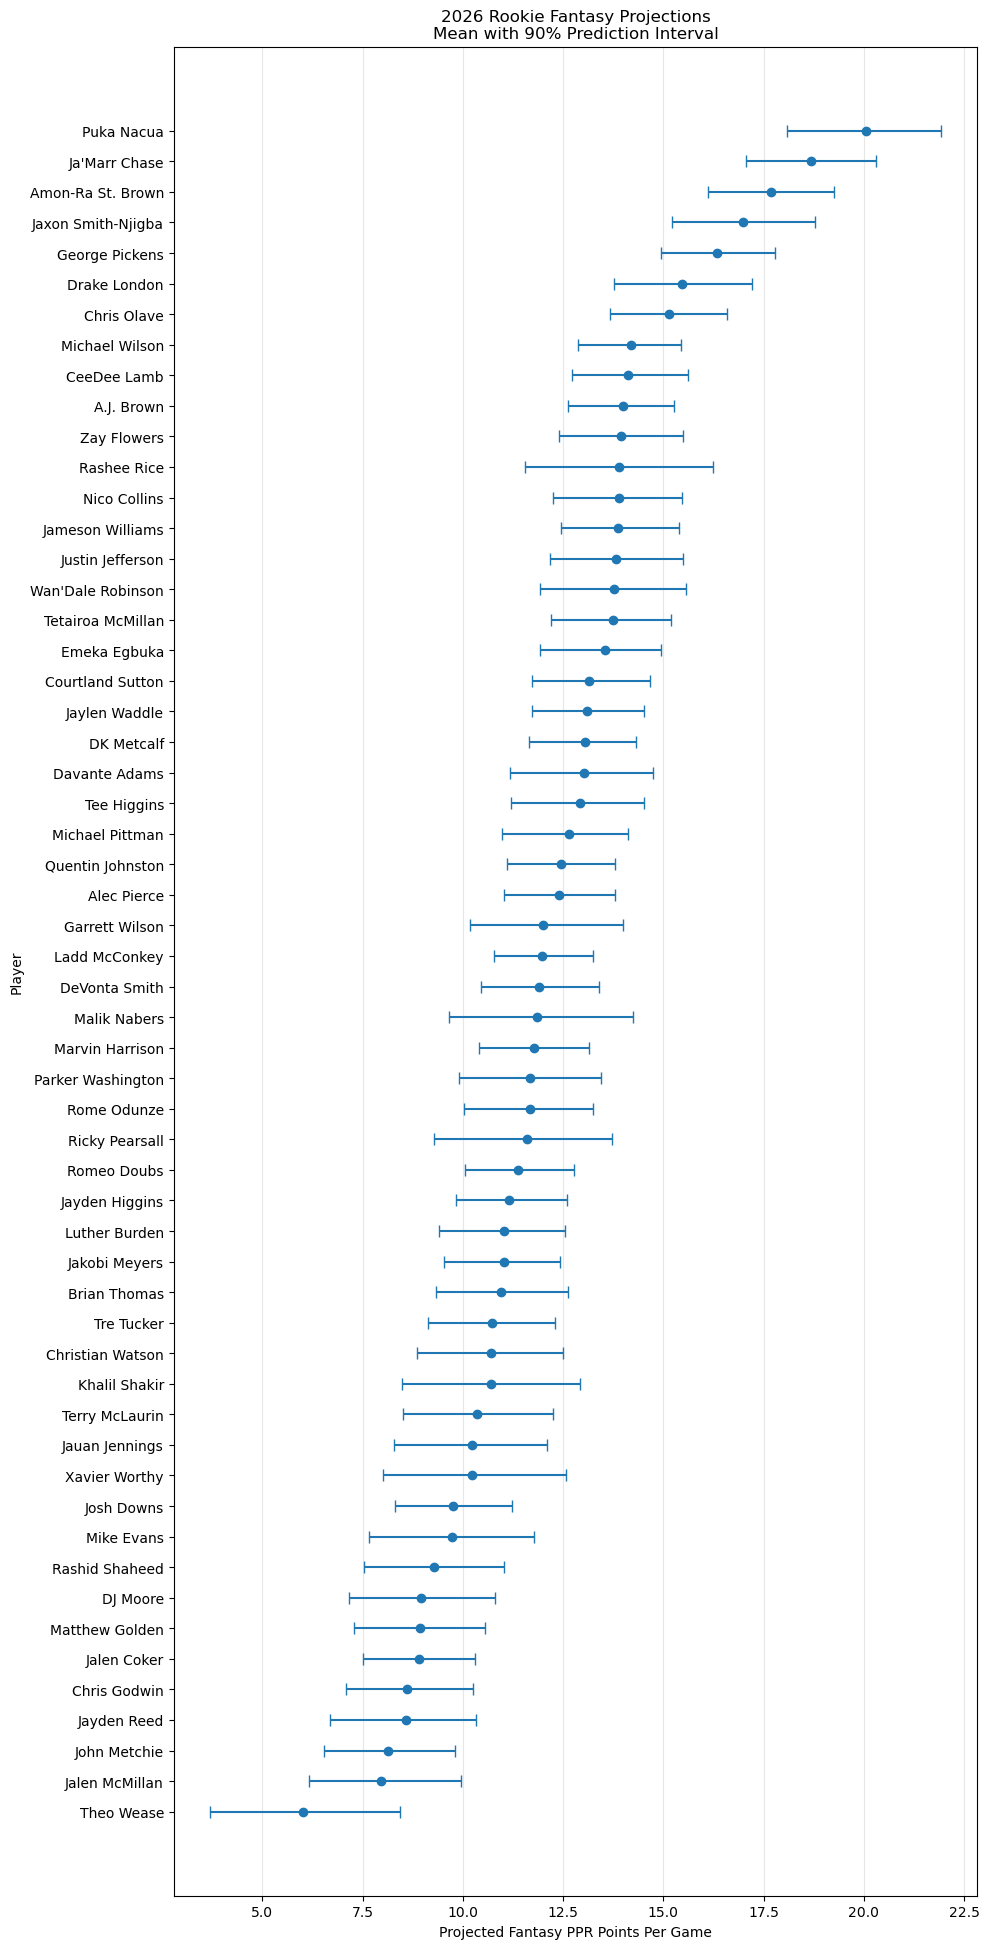

In [100]:
fig = plot_prediction_intervals(summary_ensemble)

fig.savefig(
    "../images/ensemble_2026_wr_prediction_intervals.png",
    dpi=300,
    bbox_inches="tight"
)

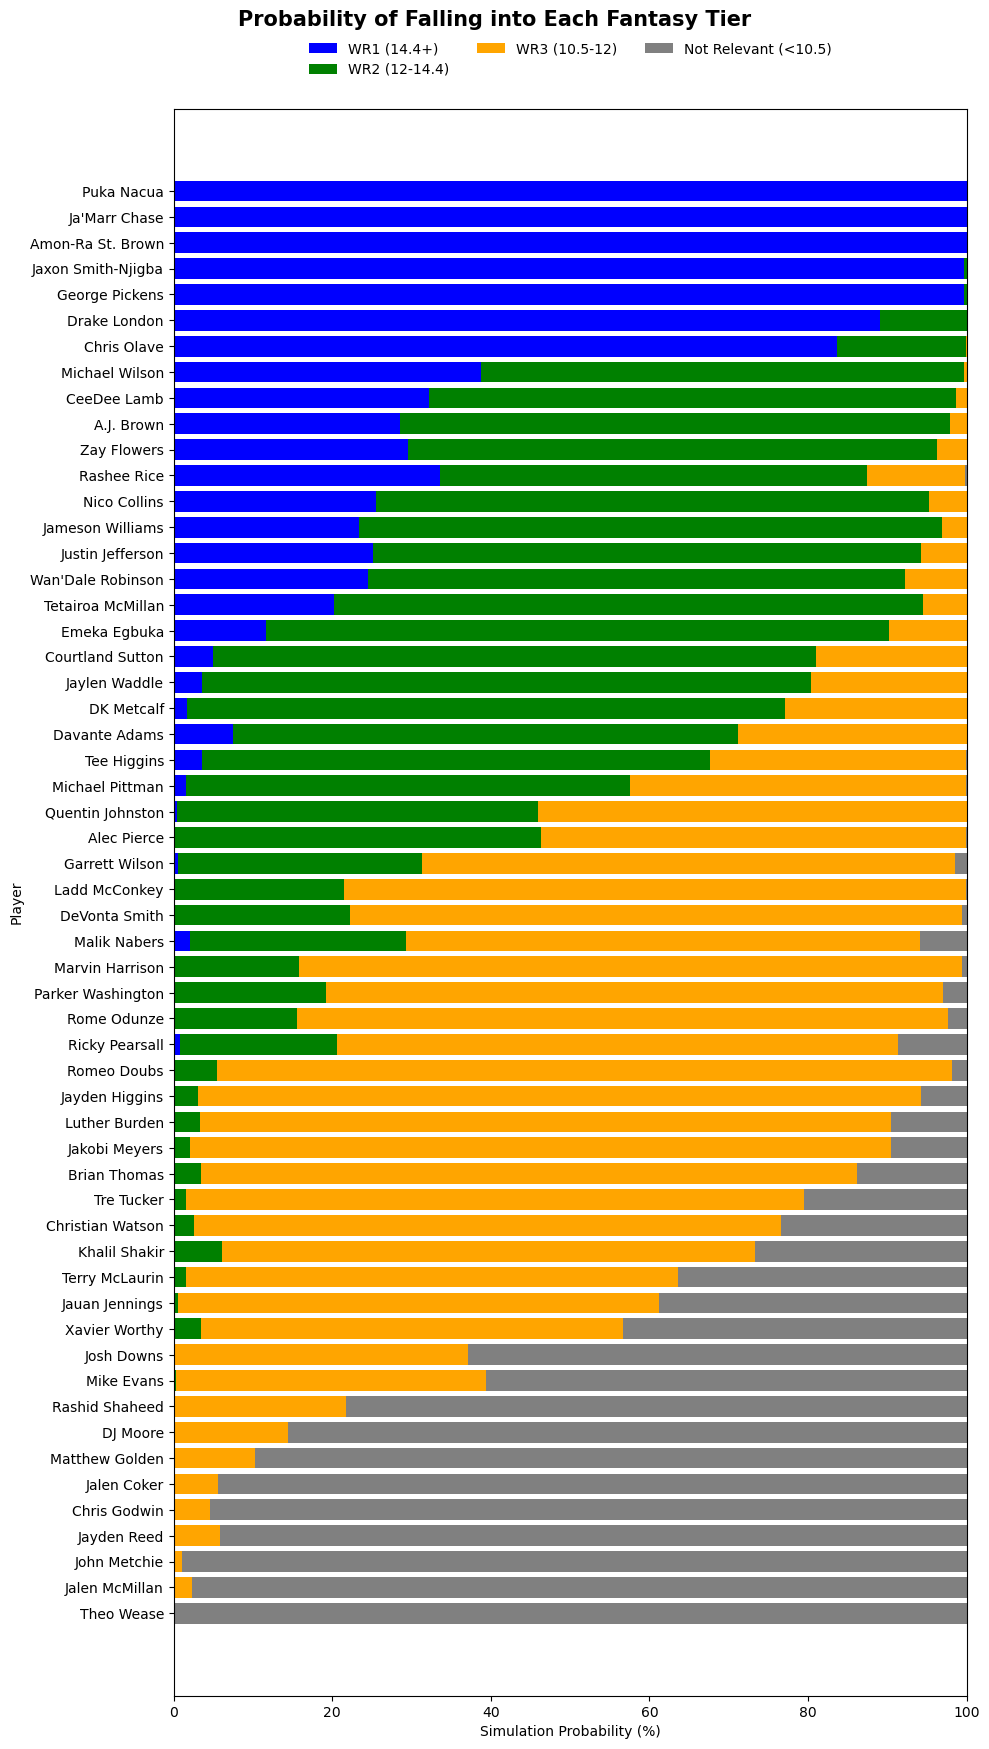

In [105]:
fig = plot_tier_probabilities(summary_ensemble)

fig.savefig(
    "../images/ensemble_2026_wr_tier_probabilities.png",
    dpi=300,
    bbox_inches="tight"
)

The tier probabilities here give more context. A guy like Rashee Rice is at WR12 but his odds at being a WR1 is at ninth best.